In [1]:
from Telescope import *

setTargetList("Ariel BDs [reduced selection]")
import Ariel

import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150

________________________________________________________________
Opening all instruments into dictionary object 'instruments'...

Ariel
  |--> Ariel BDs [reduced selection]
             |--> Ariel AIRS CH0 1.95-3.9um D=1 R=100 tau=0.18
             |--> Ariel AIRS CH0 1.95-3.9um D=1 R=3 tau=0.18
             |--> Ariel AIRS CH0 1.95-3.9um D=1 R=50 tau=0.18
             |--> Ariel AIRS CH1 3.9-7.8um D=1 R=1 tau=0.18
             |--> Ariel AIRS CH1 3.9-7.8um D=1 R=10 tau=0.18
             |--> Ariel AIRS CH1 3.9-7.8um D=1 R=30 tau=0.18
             |--> Ariel FGS1 0.6-0.8um D=1 R=1 tau=0.17
             |--> Ariel FGS2 0.8-1.1um D=1 R=1 tau=0.25
             |--> Ariel NIRSpec 1.1-1.95um D=1 R=1 tau=0.27
             |--> Ariel NIRSpec 1.1-1.95um D=1 R=10 tau=0.27
             |--> Ariel NIRSpec 1.1-1.95um D=1 R=20 tau=0.27
             |--> Ariel VISPhot 0.5-0.6um D=1 R=1 tau=0.2
________________________________________________________________



In [2]:
# Ariel.constructArielInstruments("Ariel BDs [reduced selection]")

In [3]:
visphot = Ariel.getInstrument("VISPhot")
planets = list(visphot.table["Planet Name"])

In [4]:
visphot.table[[x for x in visphot.table.columns if "Dayside" in x]]

,Dayside Emitting Temperature [K],Eclipse Dayside Temperature Uncertainty 0.5-0.6um,Full Phase Curve Dayside Temperature Uncertainty 0.5-0.6um
0,1256.931324,2.032792e+02,2.880549e+01
1,1705.143863,3.542005e+01,7.670127e+00
2,507.613777,7.749196e+13,7.959450e+12
3,1261.713182,8.934084e+02,8.795304e+01
4,2042.503376,2.131757e-01,5.171329e-02
5,350.867579,8.072798e+24,3.792765e+24
6,456.021583,1.313246e+16,1.541136e+15
7,1528.466250,1.405417e+01,3.137968e+00
8,1472.629550,6.429344e+01,6.300705e+00
9,779.086118,4.289250e+07,2.033493e+06


In [5]:
def plotParamOverview(param, planets, ylabel=None, tier=1, param_units=None, columns=4, figsize=(6, 3), iterations=1, include_photometry=False, only_photometry=False, xscale="log", yscale="log"):

    rows = int(np.ceil(len(planets) / columns))
    
    
    if only_photometry == True:
        include_photometry = True

    fig, ax = plt.subplots(rows, columns, figsize=(figsize[0]*columns, figsize[1]*rows), sharex=True)    

    planet_index = 0
    
    for i in range(0, rows):
        for j in range(0, columns):
            if planet_index >= len(planets):
                break
            planet = planets[planet_index]

            ax[i,j].set_xscale(xscale)
            ax[i,j].set_yscale(yscale)

            telescopes = []
            for telescope in Ariel.getTieredInstruments(tier)[0]:
                if not include_photometry and telescope in ["VISPhot", "FGS1", "FGS2"]:
                    continue
                if only_photometry and telescope not in ["VISPhot", "FGS1", "FGS2"]:
                    continue
                tel = Ariel.getInstrument(telescope)
                tel.plotParam(planet, param, ax=ax[i,j], marker='.', iterations=iterations, ppm=False)
                telescopes.append(tel)

            Ariel.plotSensitivityRange(instruments=telescopes, ax=ax[i,j])
            ax[i,j].set_title(planet, pad=2)
        
            if i == rows-1:
                ax[i,j].set_xlabel(r"Wavelength $[\mu m]$")
            if j == 0:
                if ylabel is None:
                    if 'uncertainty' in param.lower():
                        ylabel = f"Relative {param}"
                    else:
                        ylabel = f"{param}"
                    
                    if param_units is not None:
                        ylabel += r" [${}$]".format(param_units)
                ax[i,j].set_ylabel(ylabel)

            planet_index += 1
        
        fig.suptitle(f"{param} Overview for Ariel Instruments at Tier {tier} Spectral Resolution", fontsize=22, y=0.92)

    return fig, ax

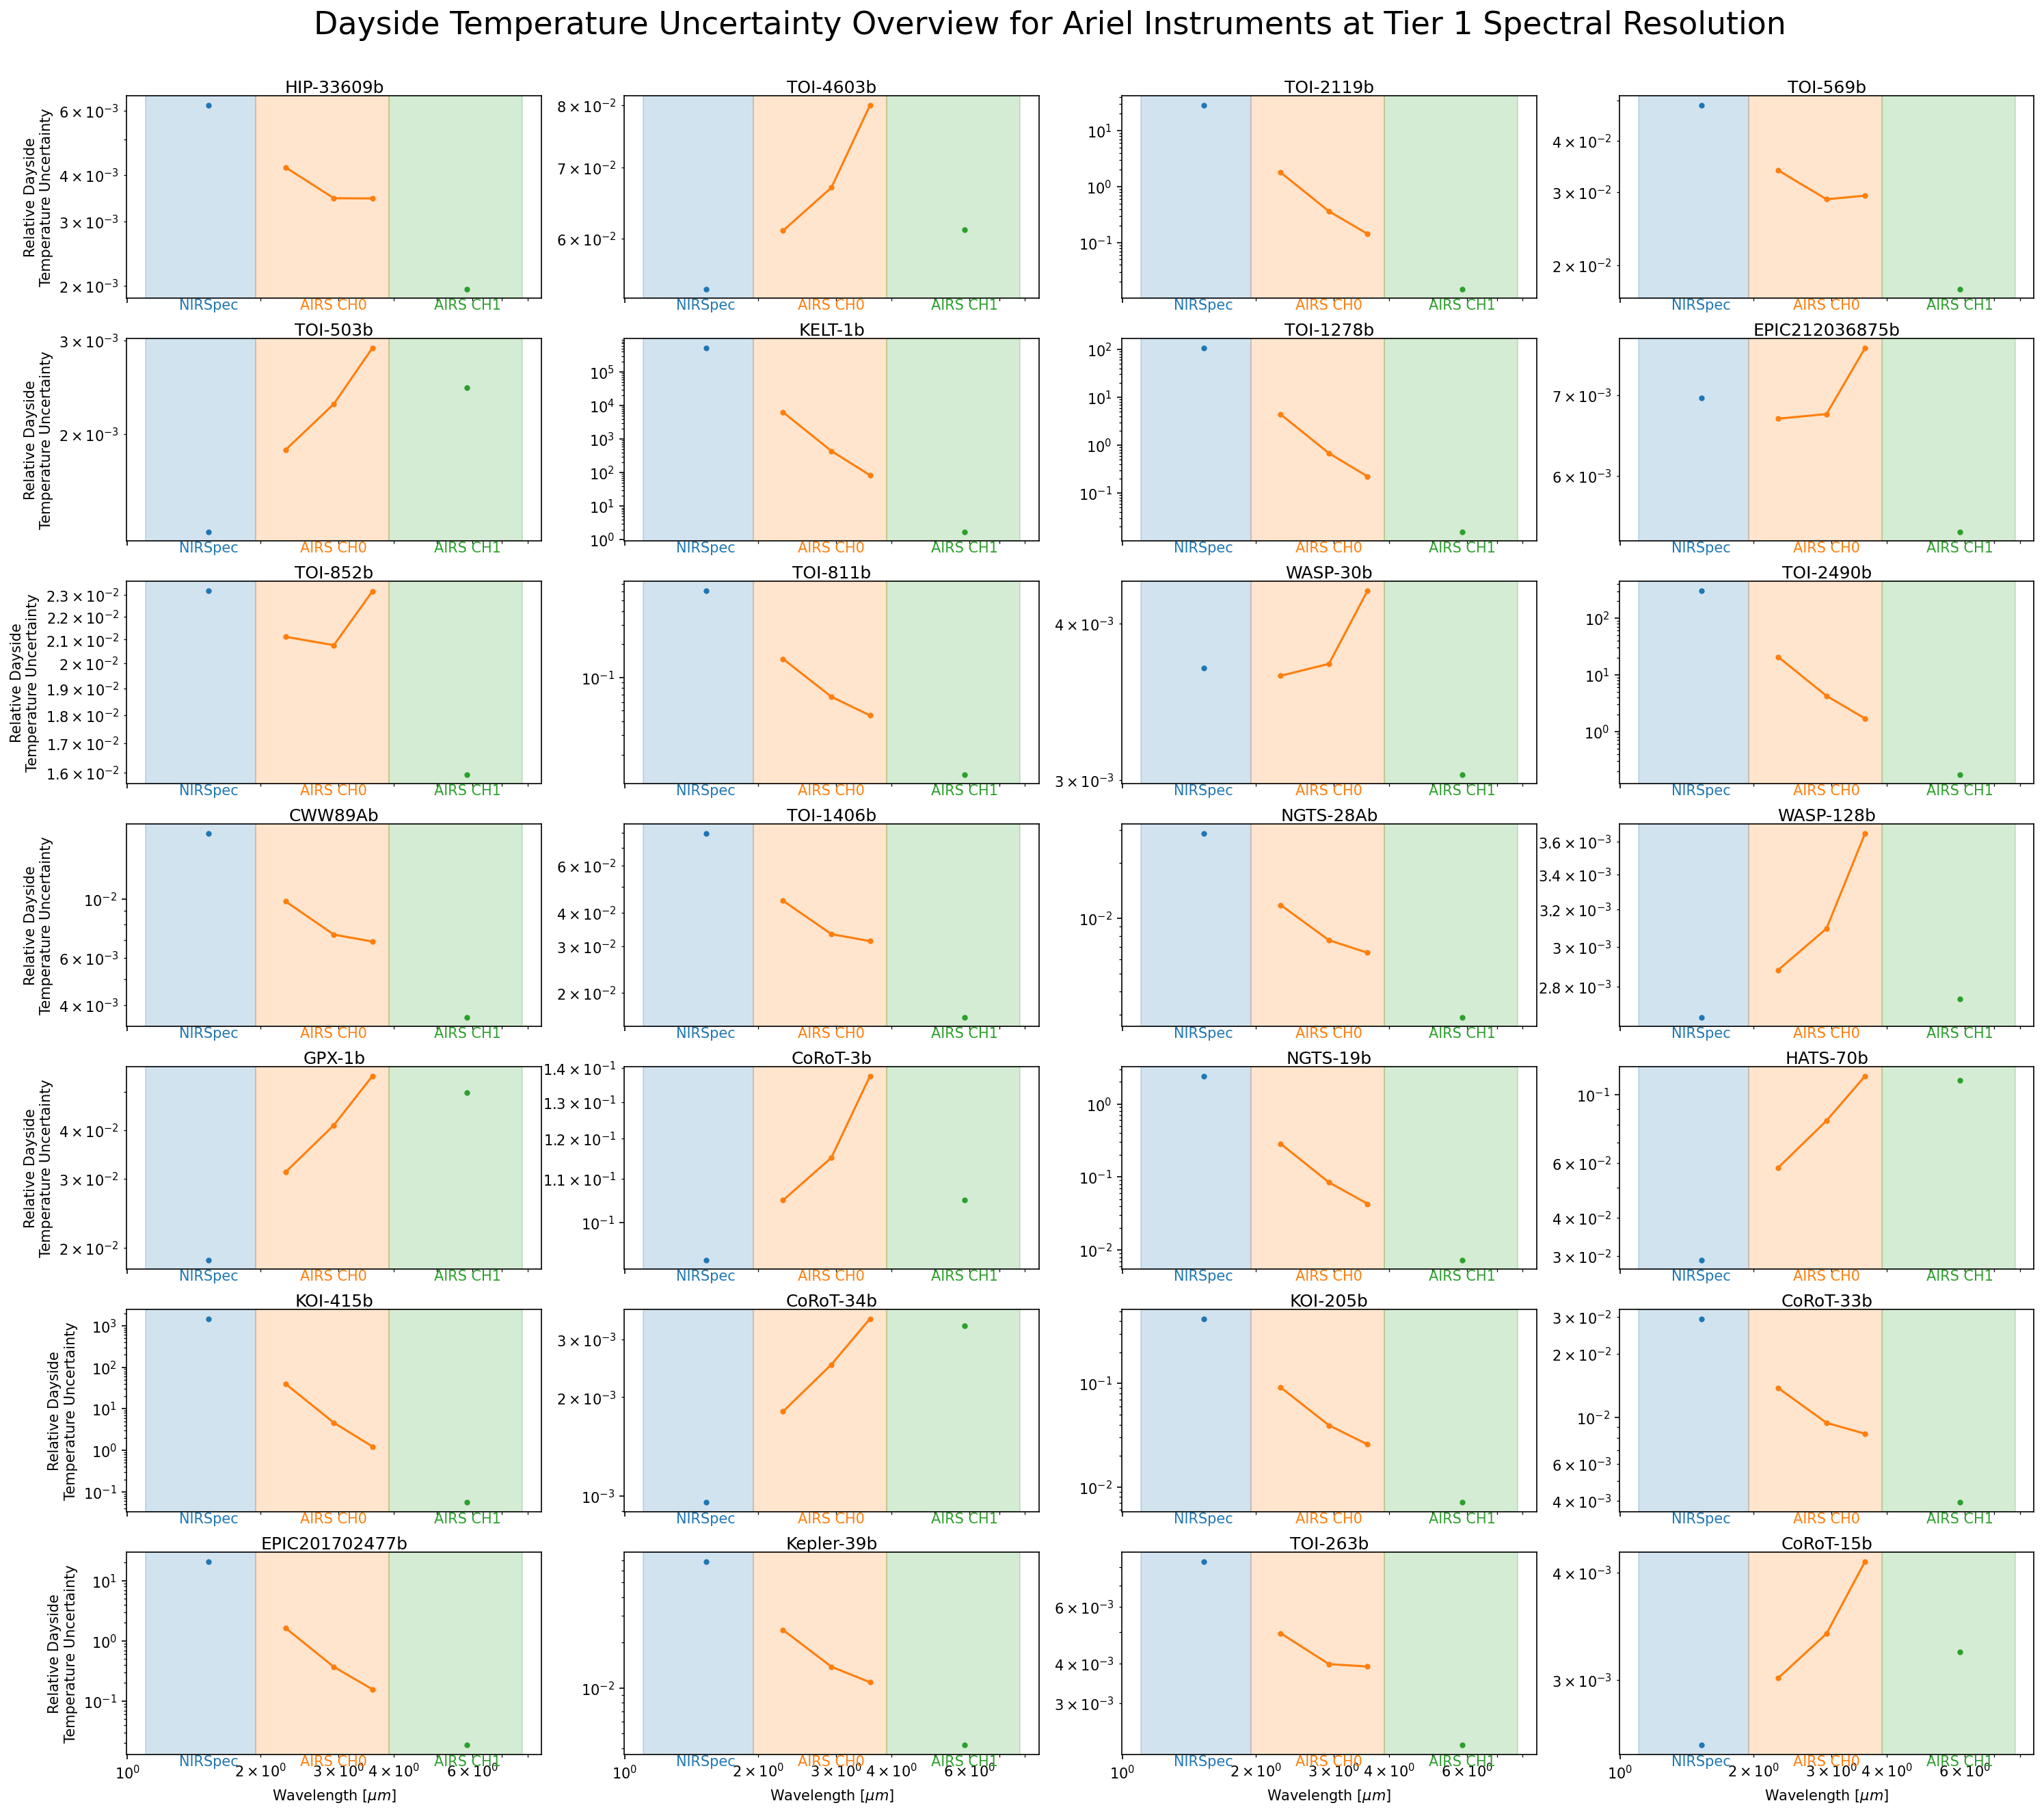

In [6]:
fig, ax = plotParamOverview("Dayside Temperature Uncertainty", planets=planets, ylabel="Relative Dayside\nTemperature Uncertainty", 
                  tier=1, figsize=(6, 3), iterations=1, include_photometry=False)

plt.show()

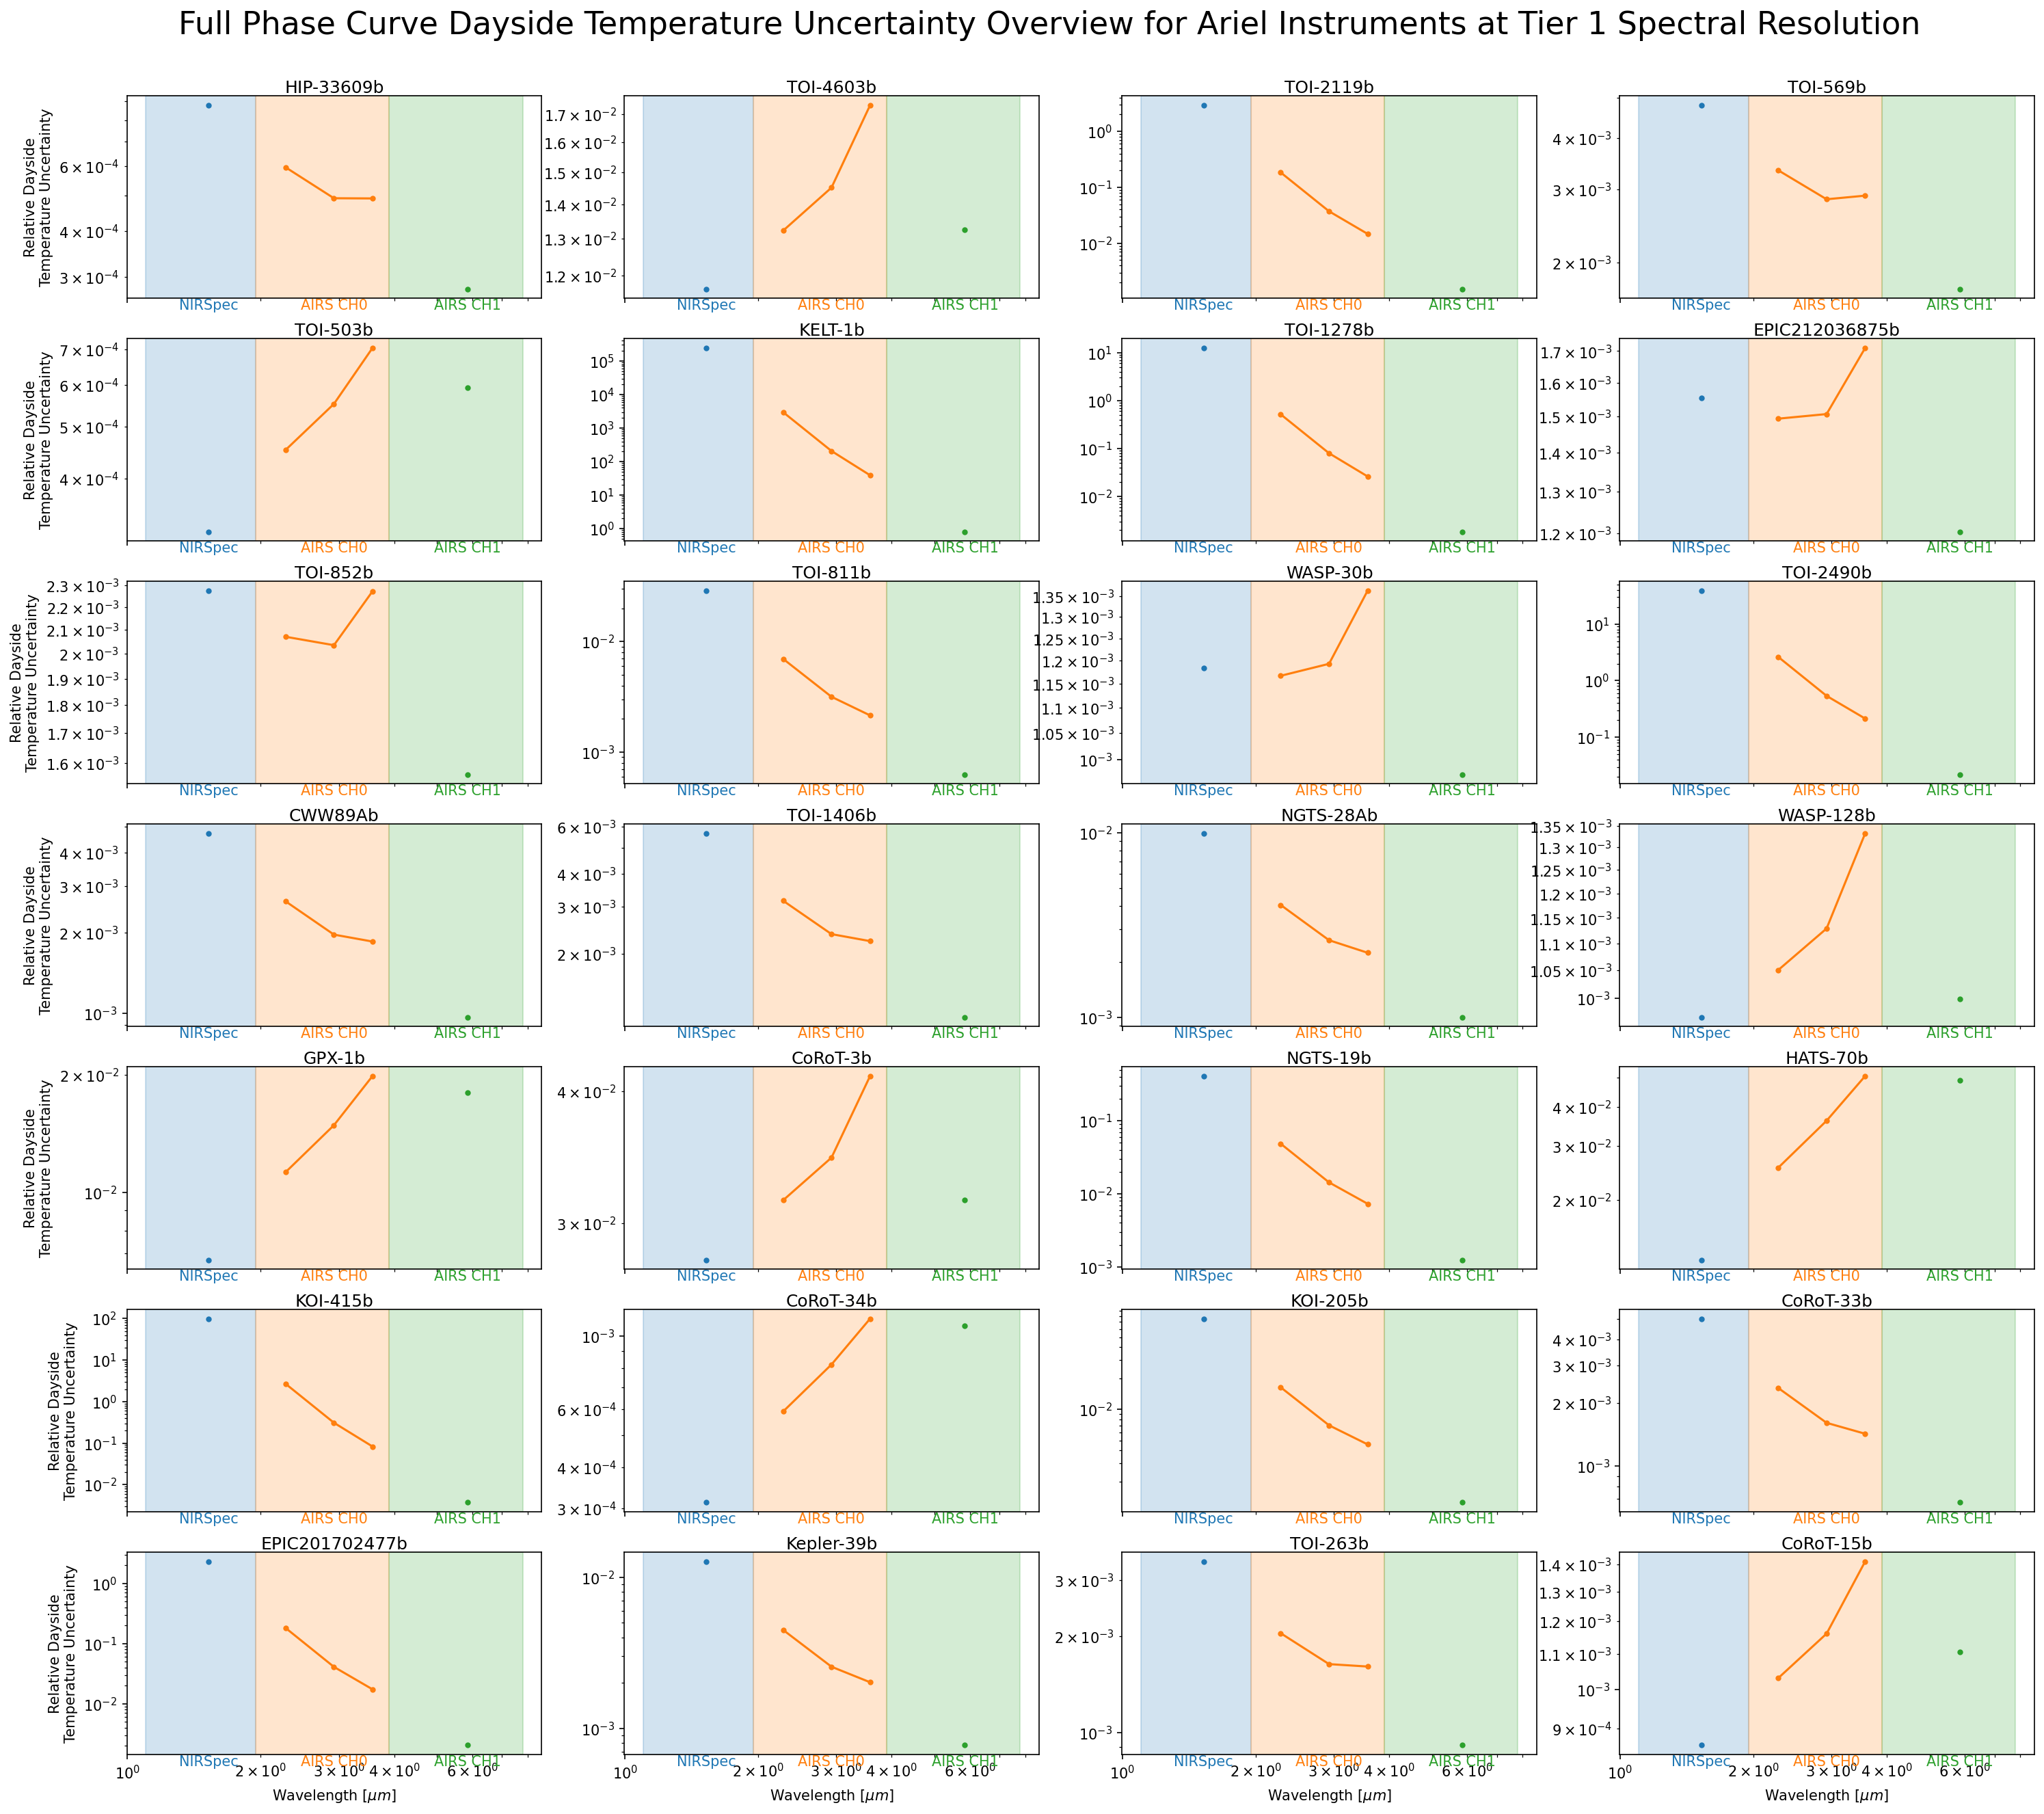

In [7]:
fig, ax = plotParamOverview("Full Phase Curve Dayside Temperature Uncertainty", planets, ylabel="Relative Dayside\nTemperature Uncertainty", 
                  tier=1, figsize=(6, 3), iterations=1, include_photometry=False)

plt.show()

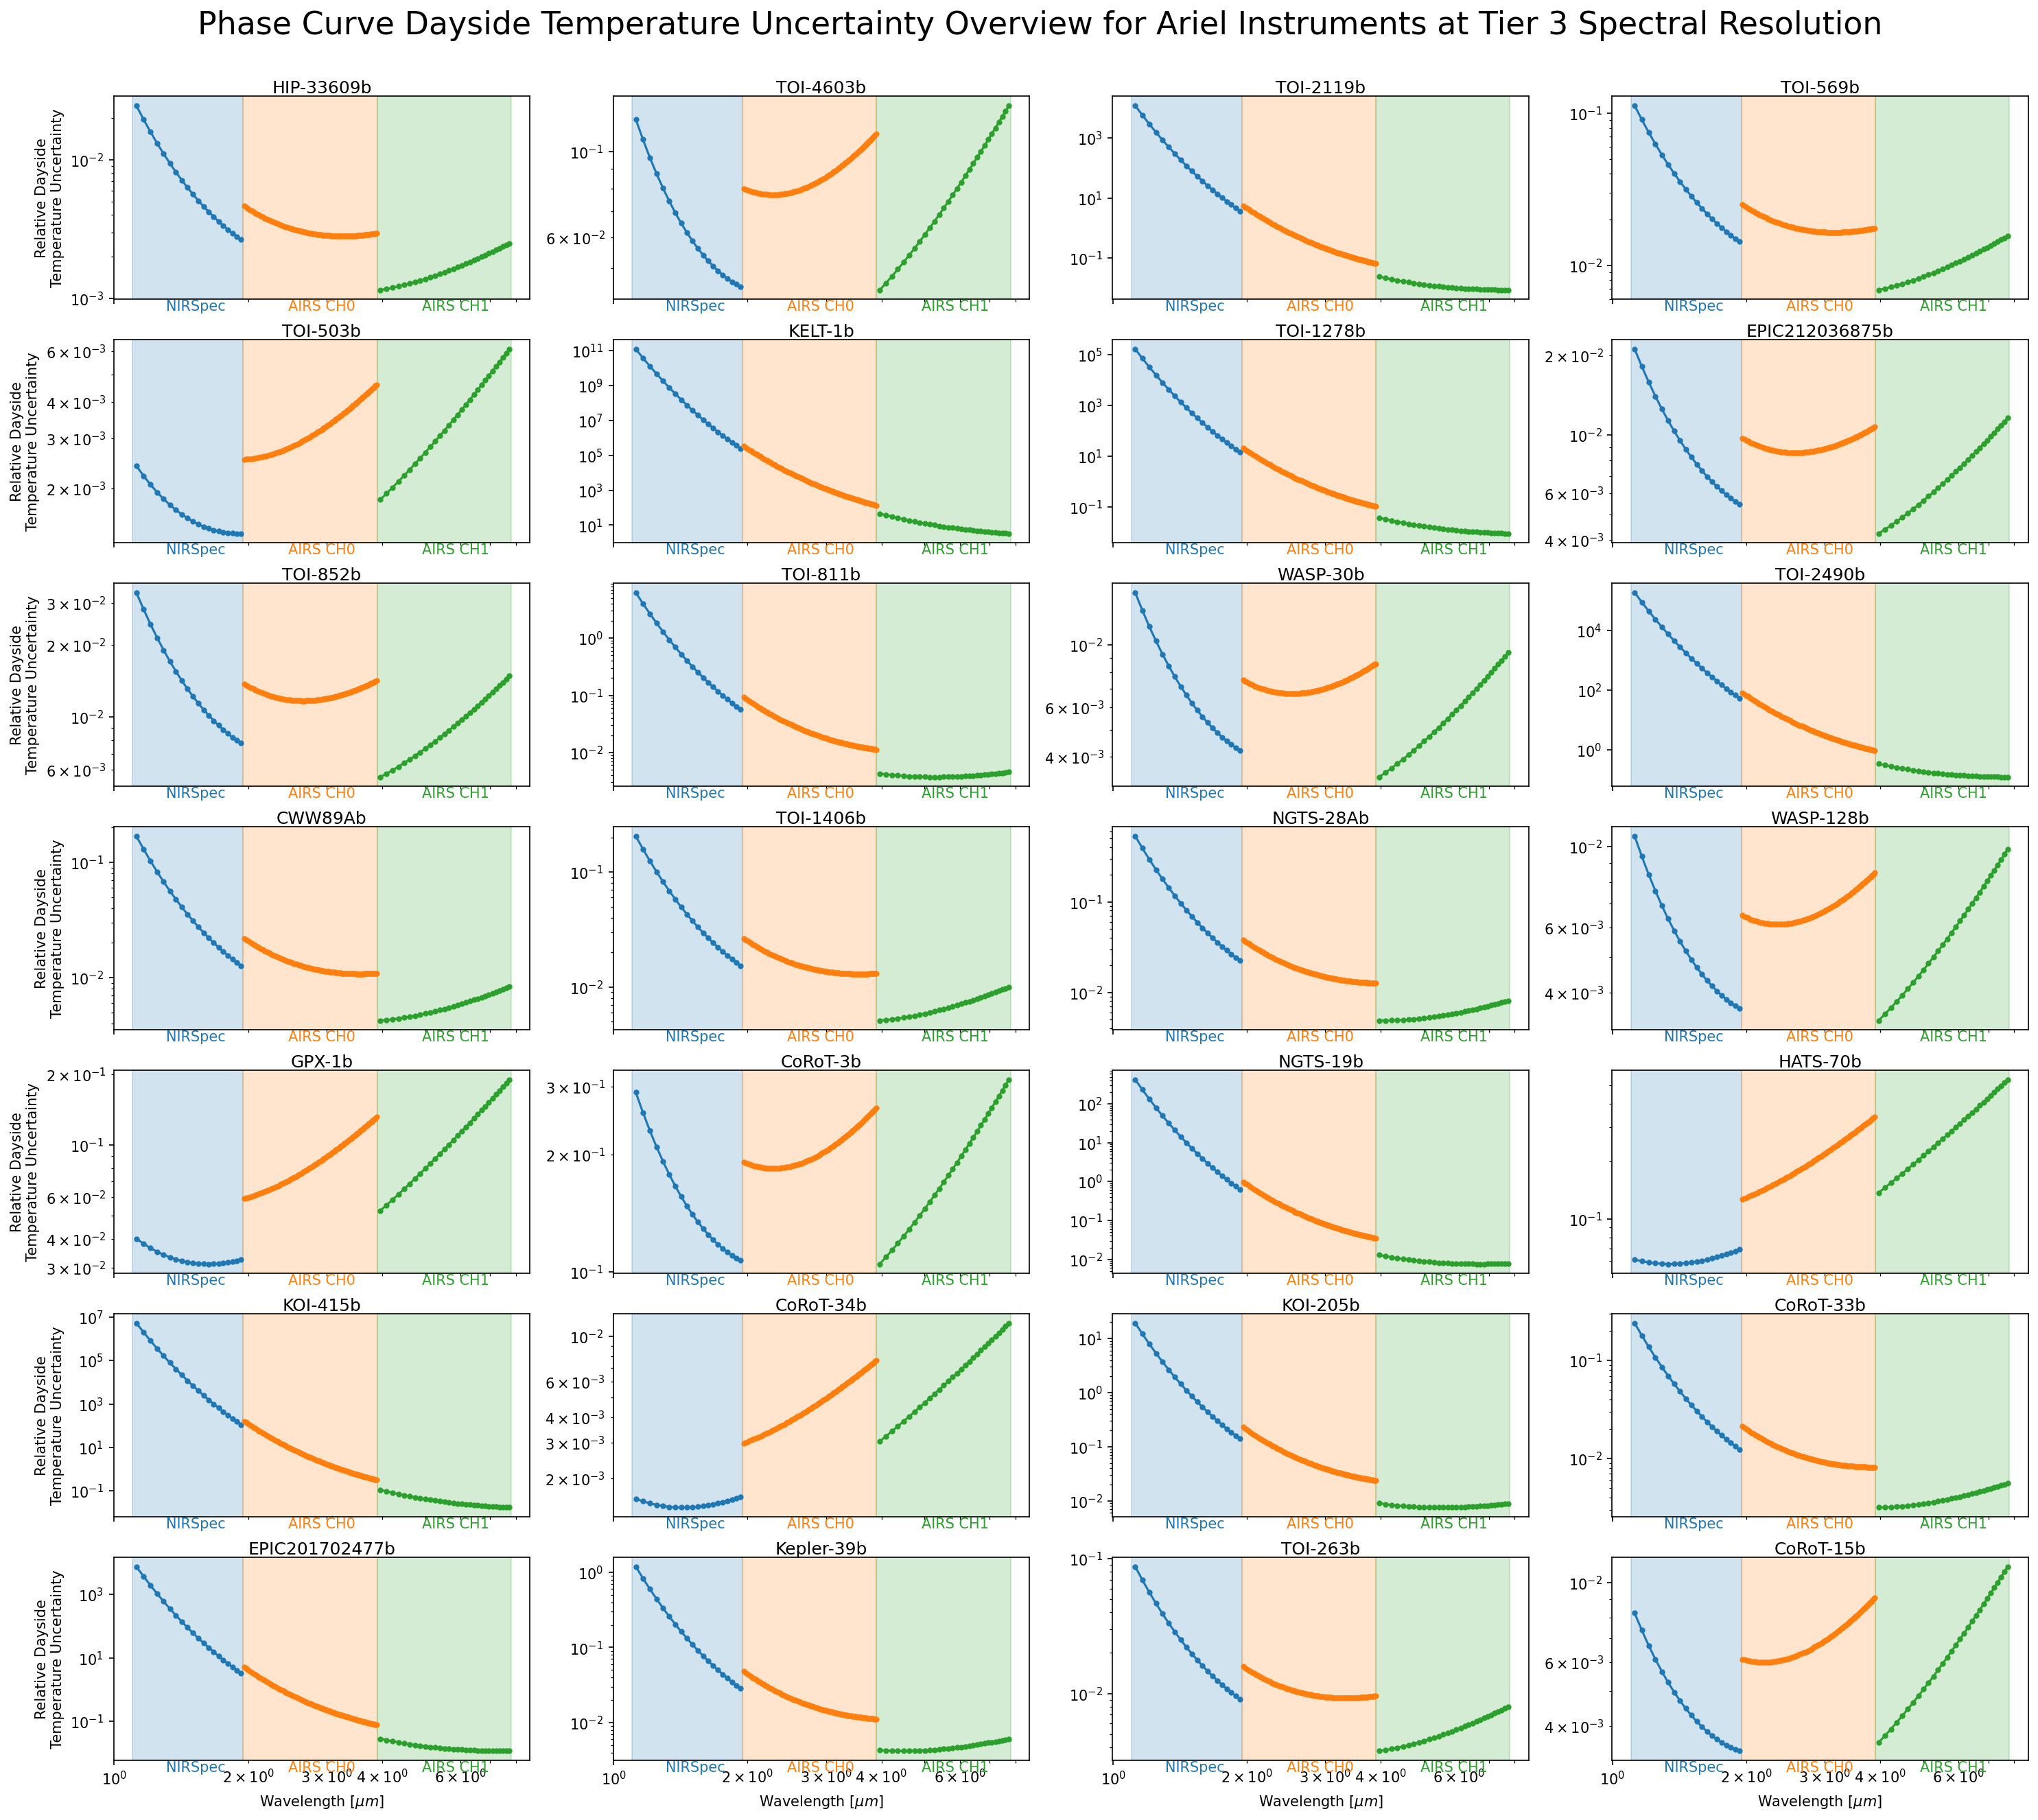

In [8]:
fig, ax = plotParamOverview("Phase Curve Dayside Temperature Uncertainty", planets, ylabel="Relative Dayside\nTemperature Uncertainty", 
                  tier=3, figsize=(6, 3), iterations=1, include_photometry=False)

plt.show()

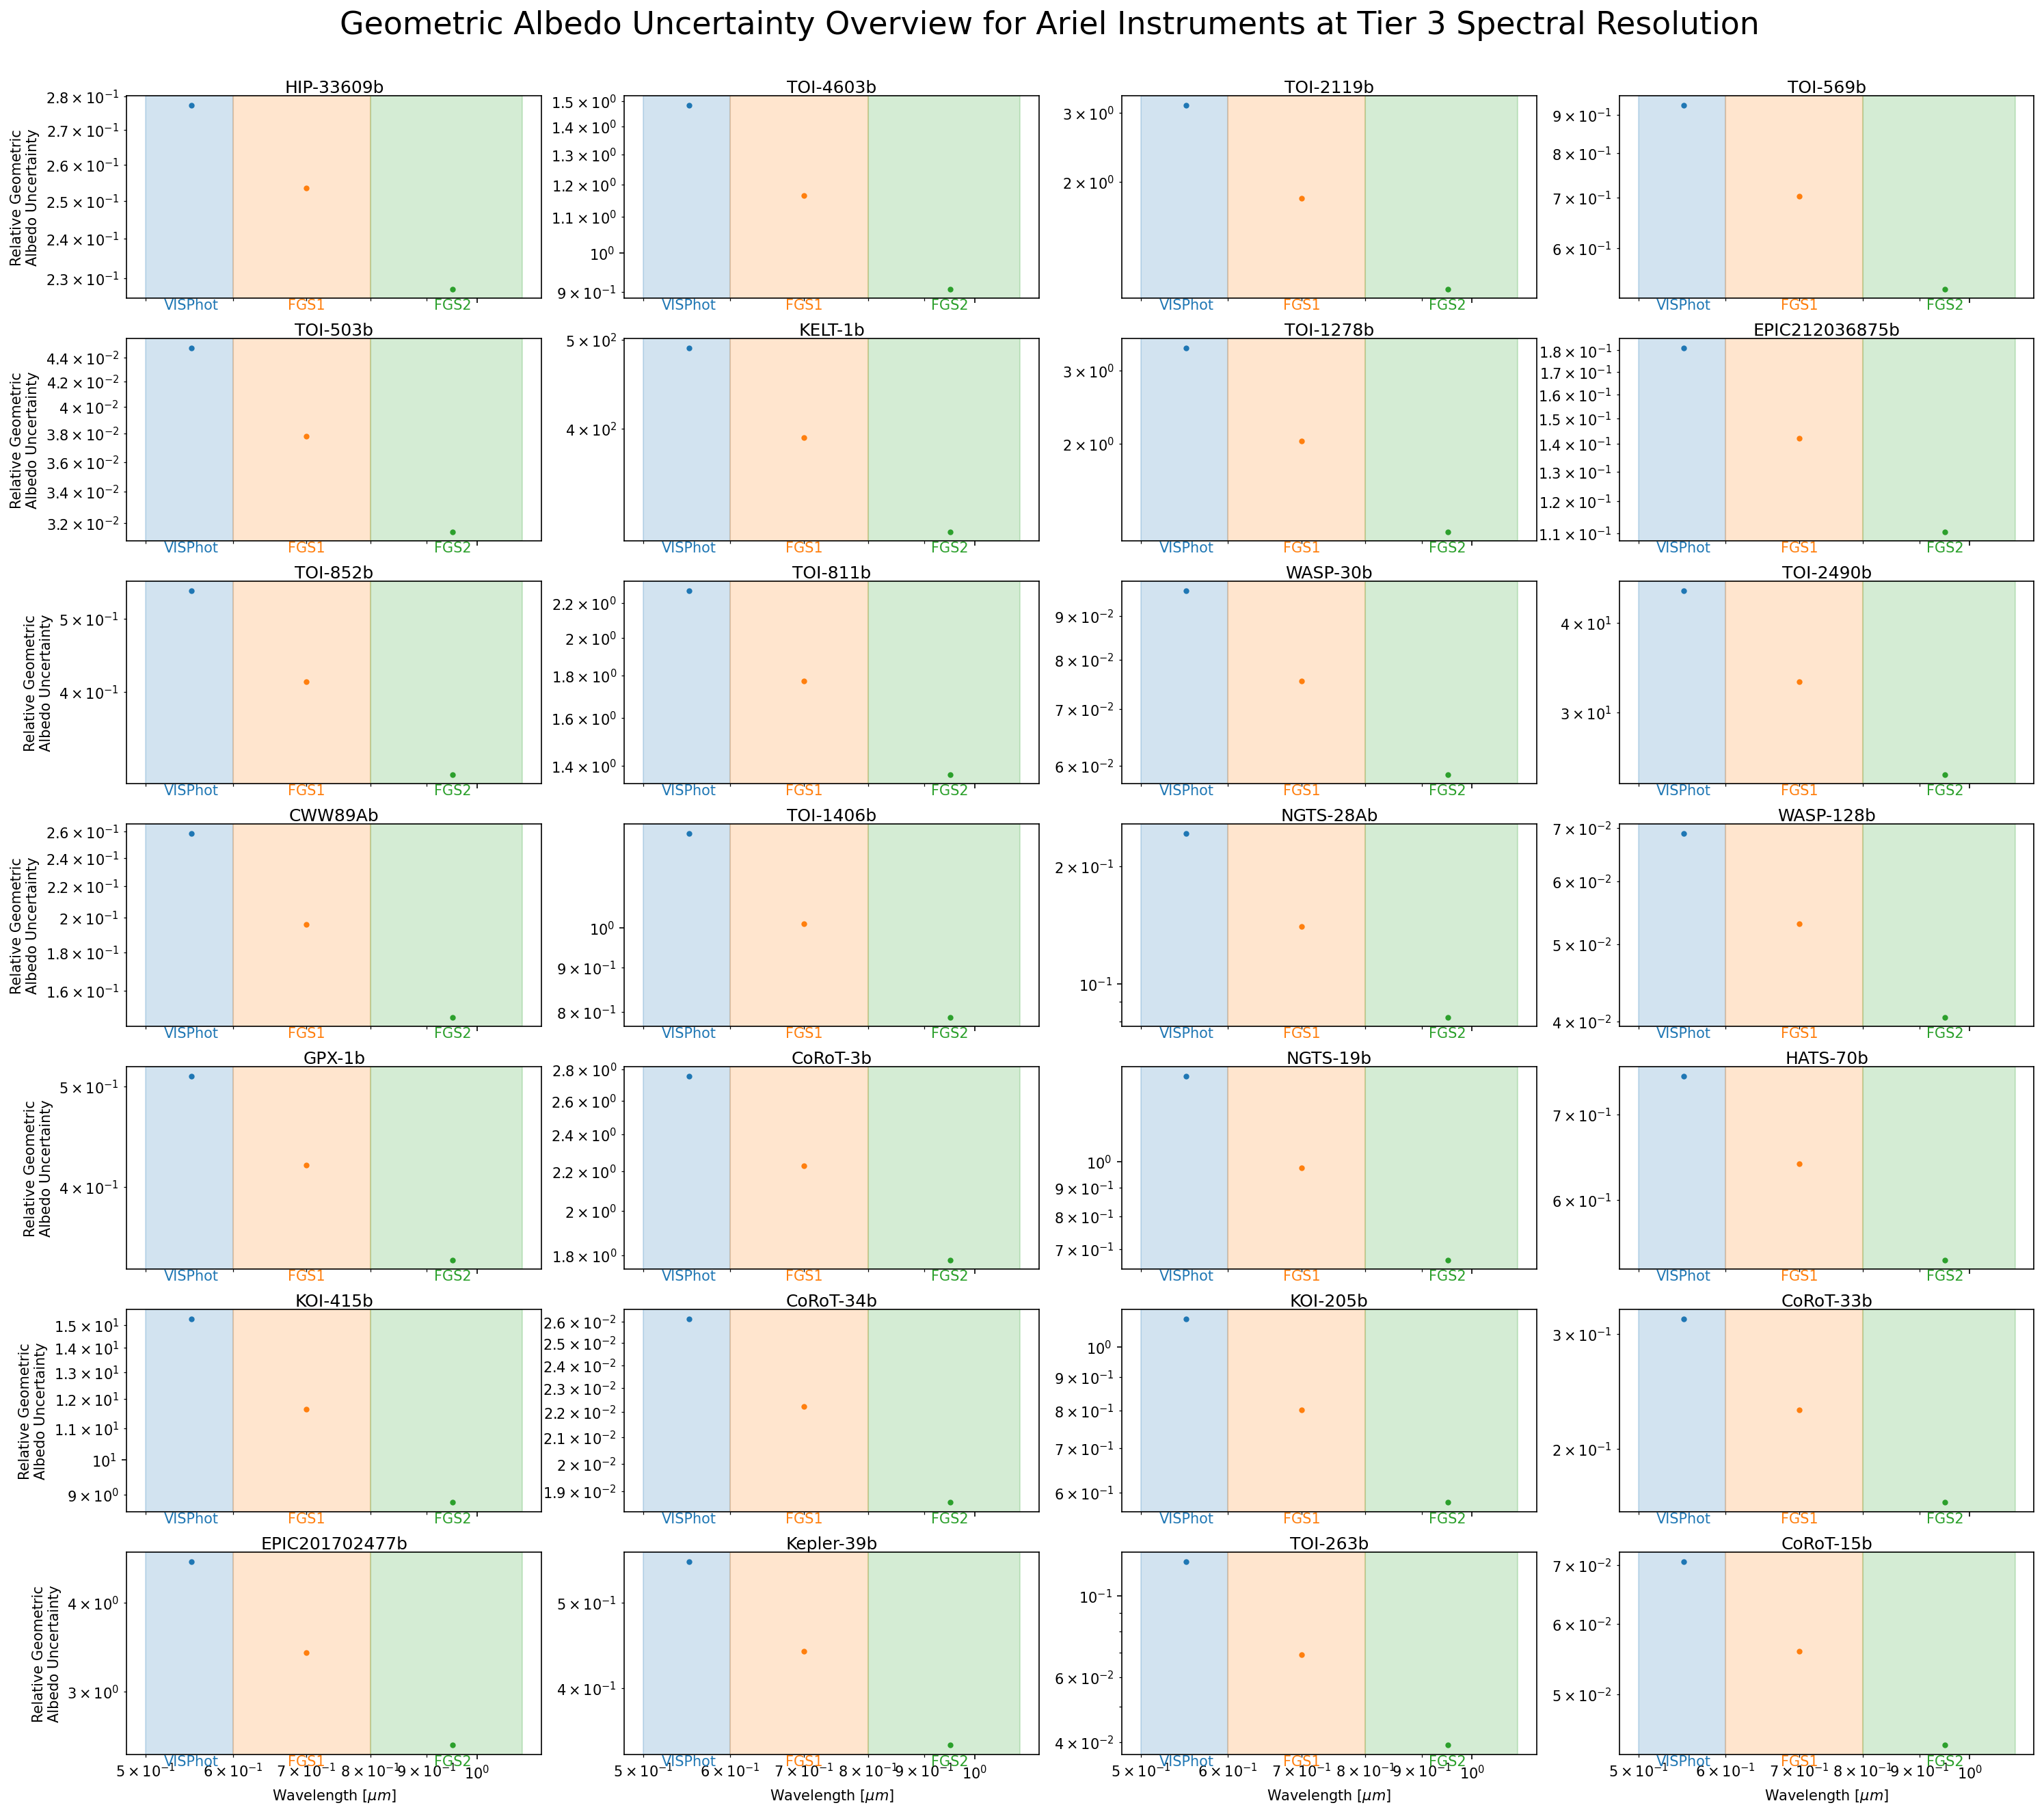

In [9]:
fig, ax = plotParamOverview("Geometric Albedo Uncertainty", planets, ylabel="Relative Geometric\nAlbedo Uncertainty", 
                  tier=3, figsize=(6, 3), iterations=1, only_photometry=True)

plt.show()

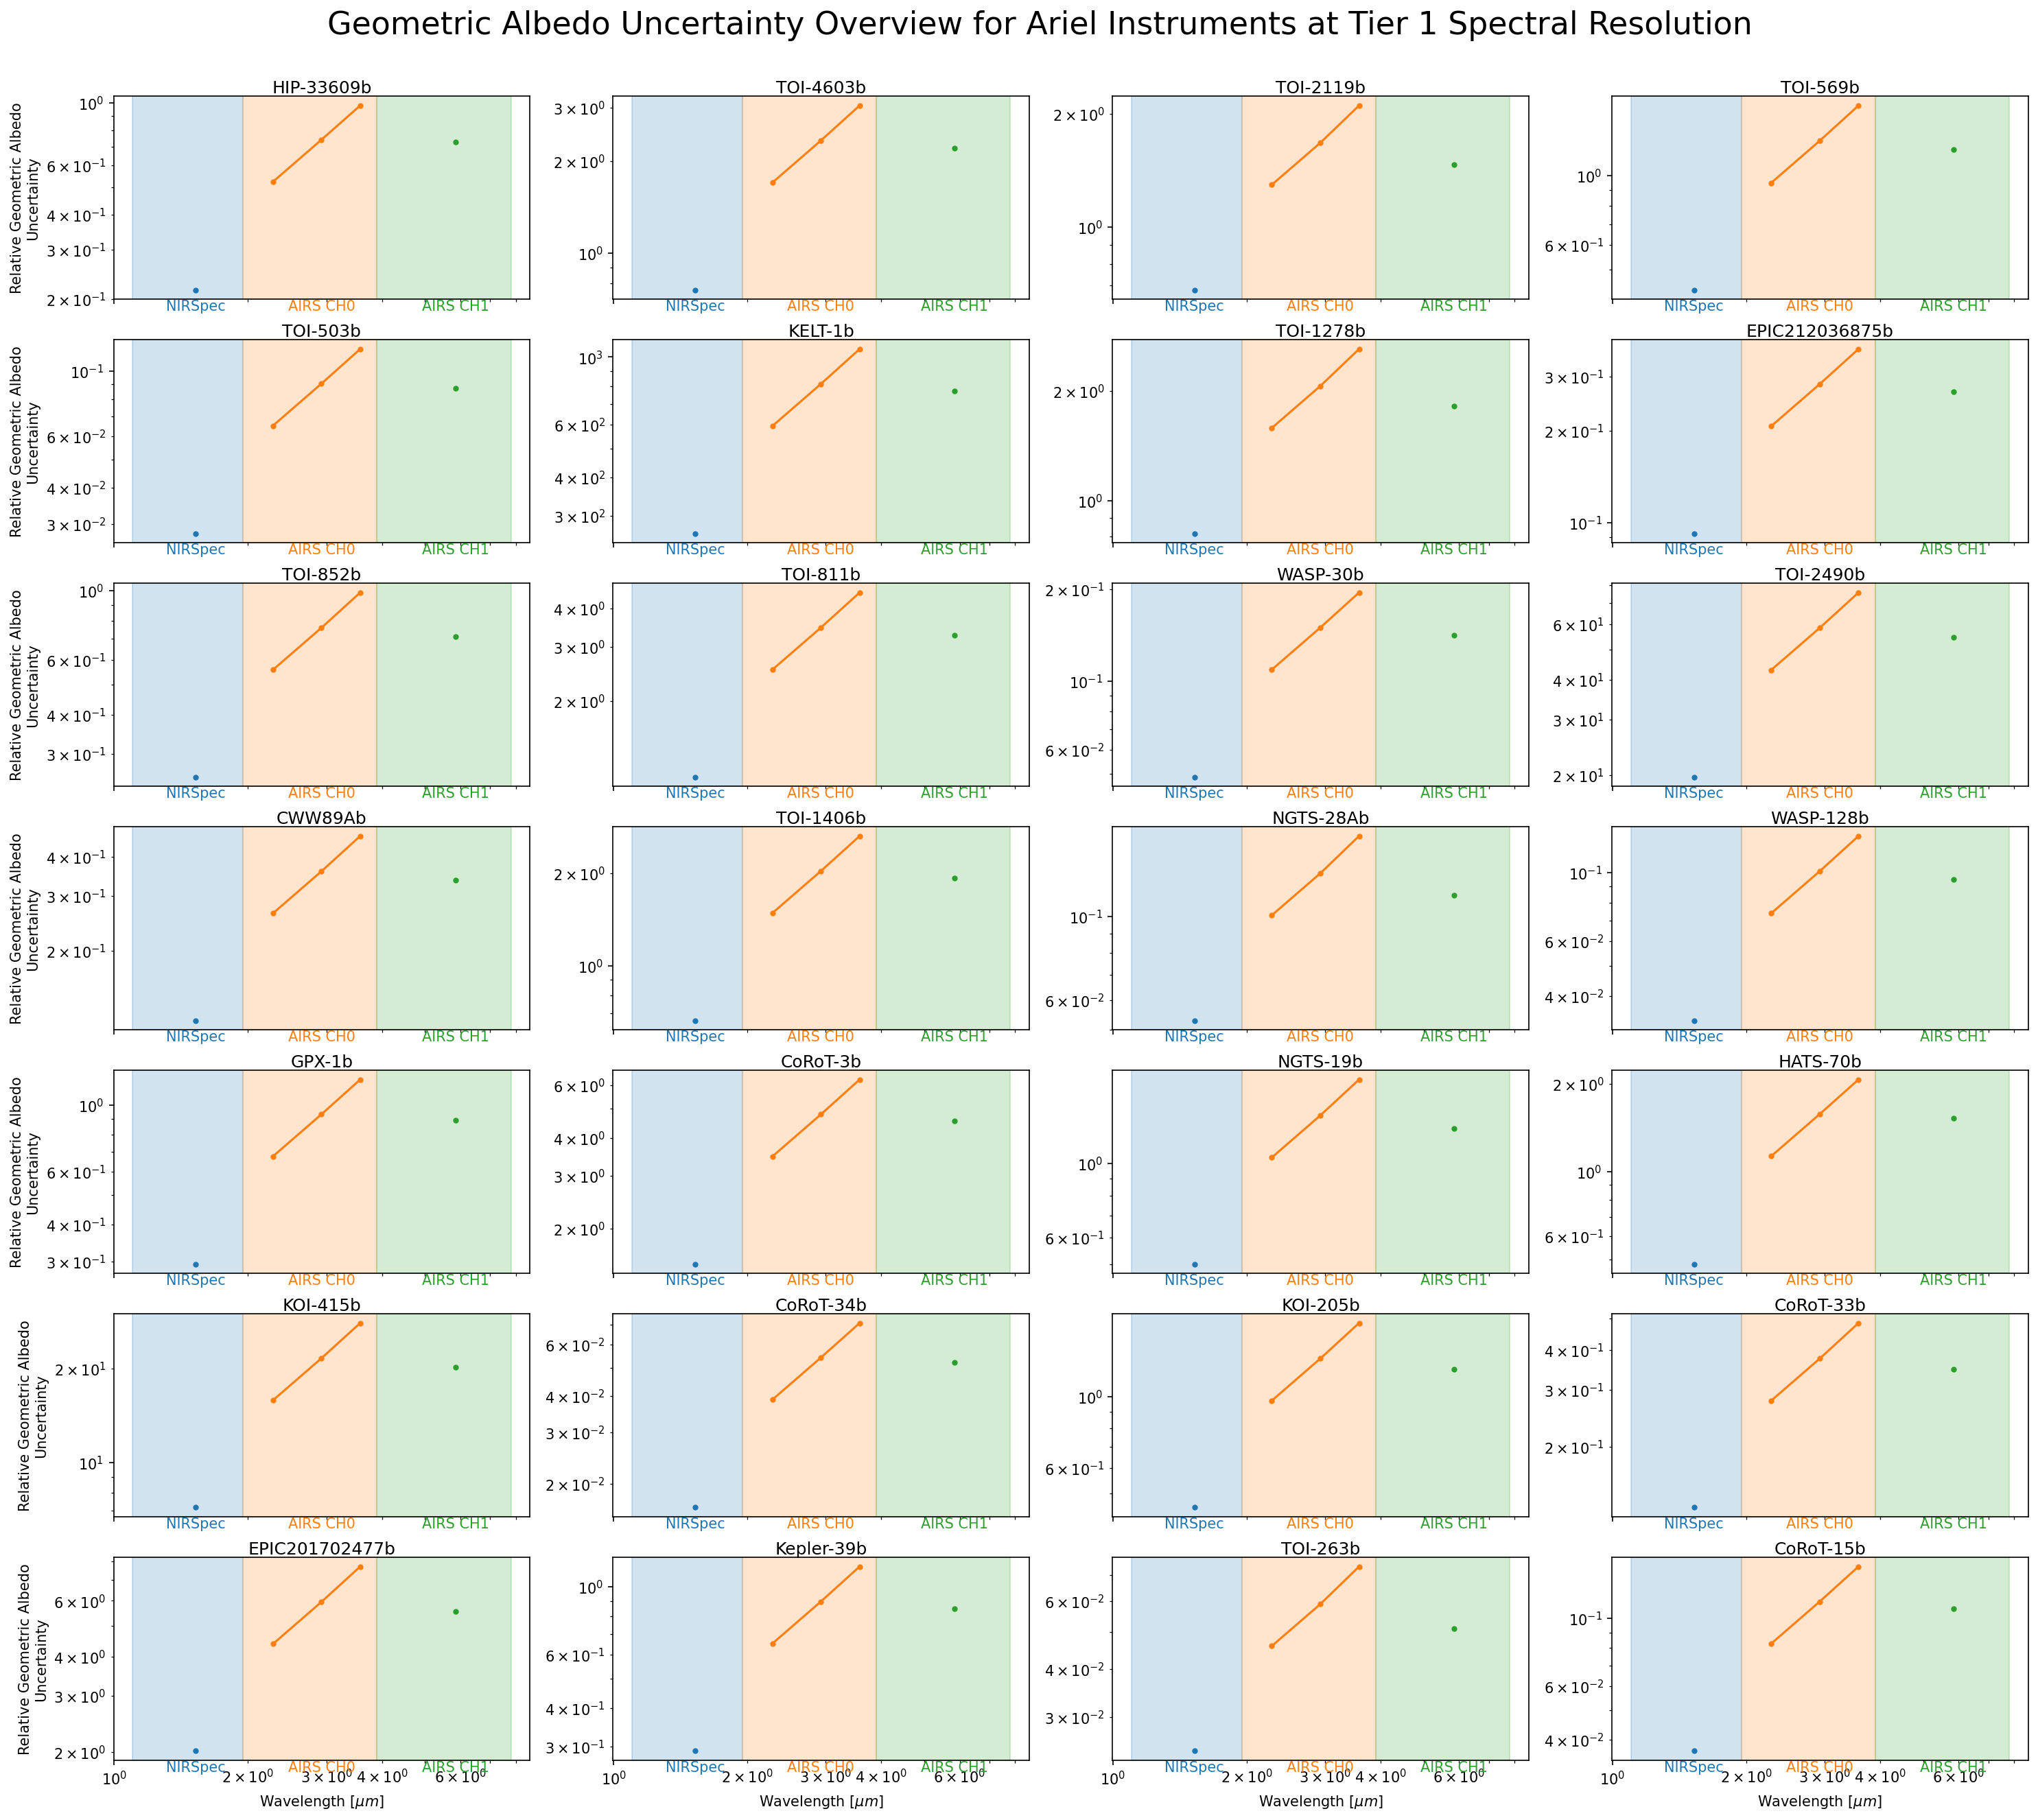

In [10]:
fig, ax = plotParamOverview("Geometric Albedo Uncertainty", planets, ylabel="Relative Geometric Albedo\nUncertainty", 
                  tier=1, figsize=(6, 3), iterations=1, include_photometry=False)

plt.show()

In [13]:
# plt.plot(visp)

In [14]:
# tier = 3
# mpl.rcParams['figure.dpi'] = 72
# for planet in planets:
#     fig, ax = plt.subplots()

#     ax.set_xscale("log")
#     ax.set_yscale("log")

#     for telescope in Ariel.getTieredInstruments(tier)[0]:
#         tel = Ariel.getInstrument(telescope)
#         tel.plotParam(planet, 'Phase Curve Dayside Temperature Uncertainty', ax=ax, marker='.', iterations=1)

#     Ariel.plotSensitivityRange(ax=ax)
#     ax.set_title(planet)
#     ax.set_ylabel("Relative Dayside Emitting\nTemperature Uncertainty " + r"$[K]$")
#     ax.set_xlabel(r"Wavelength $[\mu m]$")

#     plt.show()

In [15]:
# fig, ax = plt.subplots()

# ax.plot(range(0, len(visphot.table)), visphot.table[""])

In [16]:
# Ariel.constructObservationTable("Ariel BDs [reduced selection]", show=True)

In [17]:
obs_table = Ariel.getObservationTable("Ariel BDs [reduced selection]")
obs_table.head()

,Planet Name,Reference,Notes,Planet Period [days],Planet Mass [Mjup],Mass Error Upper (Mjup),Mass Error Lower (Mjup),Planet Radius [Rjup],Radius Error Upper (Rjup),Radius Error Lower (Rjup),...,Tier 2 Observations Full Phase Curve SNR,Tier 2 SNR Full Phase Curve SNR,Tier 3 Observations ESM,Tier 3 SNR ESM,Tier 3 Observations TSM,Tier 3 SNR TSM,Tier 3 Observations RSM,Tier 3 SNR RSM,Tier 3 Observations Full Phase Curve SNR,Tier 3 SNR Full Phase Curve SNR
0,HIP-33609b,[31],bright - also ~150 Myr . BD is large. B star host,39.47,68.0,7.40,7.10,1.58,0.07,0.07,...,1.0,165.415803,1.0,17.024523,93.0,7.012463,7.0,7.451011,1.0,120.141386
1,TOI-4603b,[1],tier 2,7.25,12.9,0.58,0.57,1.04,0.04,0.04,...,3.0,11.733781,46.0,7.040484,29742.0,7.000112,128.0,7.024417,5.0,10.719023
2,TOI-2119b,[27],None,7.20,64.4,2.30,2.20,1.08,0.03,0.03,...,4.0,11.429977,229.0,7.014521,22578.0,7.000155,269.0,7.010903,5.0,10.091108
3,TOI-569b,[15],None,6.56,64.1,1.90,1.40,0.75,0.02,0.02,...,1.0,28.118081,13.0,7.226102,139348.0,7.000006,46.0,7.018708,1.0,20.357836
4,TOI-503b,[17],None,3.68,53.7,1.20,1.20,1.34,0.26,0.15,...,1.0,212.649686,1.0,36.151004,269.0,7.004637,1.0,18.977004,1.0,149.023919


In [18]:
def plotObsVsTarget(obs_table, obs_method, yscale="log", ax=None, tierOneColor="red", tierTwoColor="green", tierThreeColor="orange", ylabel="Number of Observations", 
                    xlabel="Target (sorted by number of observations)", legend_fontsize=8):
    if obs_method.lower().strip() == "esm":
        method = "ESM"
        label = "Emission Spectroscopy Mode"
    elif obs_method.lower().strip() == "tsm":
        method = "TSM"
        label = "Transmission Spectroscopy Mode"
    elif obs_method.lower().strip() == "rsm":
        method = "RSM"
        label = "Reflected Light Spectroscopy Mode"
    elif obs_method.lower().strip() in ["fpcsm", "fpcsnr"]:
        method = "Full Phase Curve SNR"
        label = "Full Phase Curve"
    else:
        raise ValueError("Unknown observation method. Must be one of 'ESM', 'TSM', 'RSM', 'FPCSM'. FPCSM is the same as FPCSNR, which are the signal-to-noise ratios for full phase curve observations.")
    
    if ax is None:
        fig, ax = plt.subplots()

    ax.grid(which="major", linestyle="-", alpha=0.5)
    ax.grid(which="minor", linestyle=":", alpha=0.2)
    ax.minorticks_on()

    if method != "RSM":
        ax.plot(range(0, len(obs_table)), obs_table[f"Tier 1 Observations {method}"].sort_values(), label=f"Tier 1 {label}", color=tierOneColor)
        ax.plot(range(0, len(obs_table)), obs_table[f"Tier 2 Observations {method}"].sort_values(), label=f"Tier 2 {label}", color=tierTwoColor)
        ax.plot(range(0, len(obs_table)), obs_table[f"Tier 3 Observations {method}"].sort_values(), label=f"Tier 3 {label}", color=tierThreeColor)
    else:
        ax.plot(range(0, len(obs_table)), obs_table[f"Tier 1 Observations {method}"].sort_values(), label=f"{label}", color=tierThreeColor)
        print("NOTE: Reflected light is measured by the photmetric instruments [VISPhot, FGS1, FGS2], so no tiers are defined for RSM.")

    ax.set_yscale(yscale)

    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)

    ax.legend(fontsize=legend_fontsize, fancybox=False)

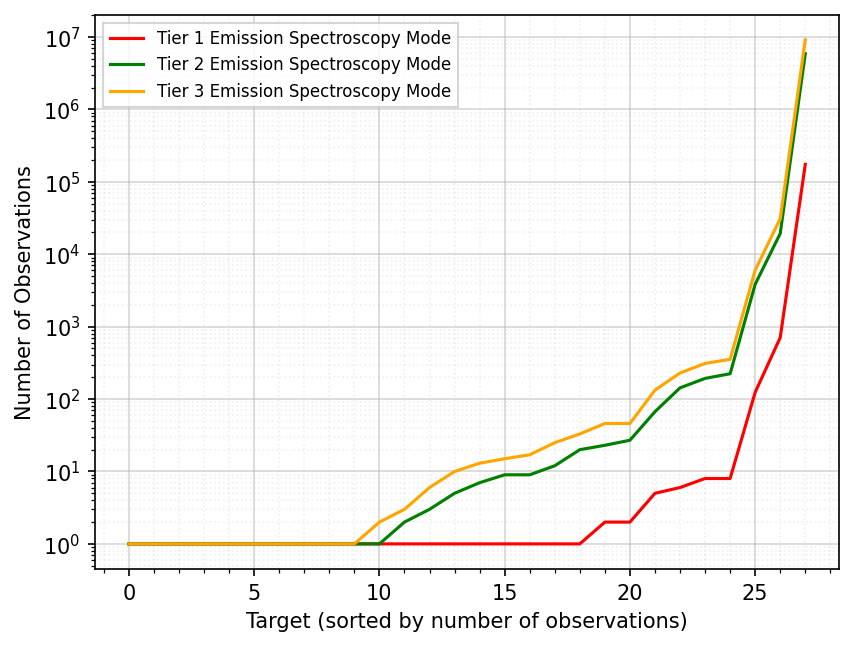

In [24]:
plotObsVsTarget(obs_table, "ESM")
plt.savefig("Results Plots/Ariel Tier 1 ESM Observations.png", dpi=300, bbox_inches="tight")
plt.show()

NOTE: Reflected light is measured by the photmetric instruments [VISPhot, FGS1, FGS2], so no tiers are defined for RSM.


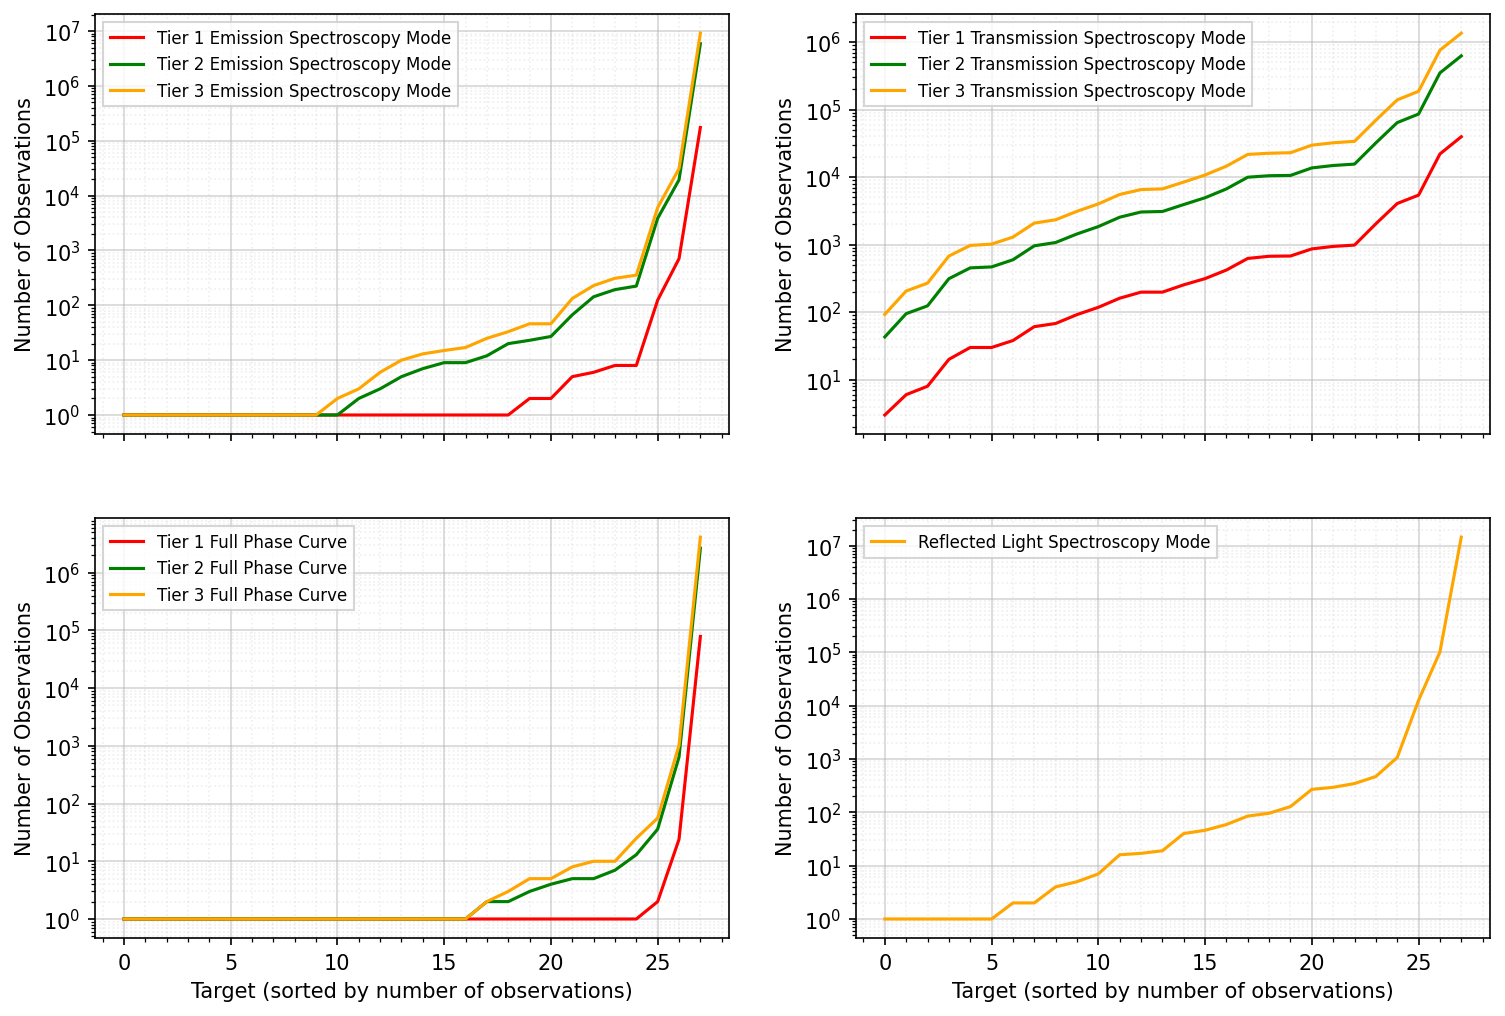

In [23]:
fig, ax = plt.subplots(2,2, sharex=True, figsize=(12,8))

plotObsVsTarget(obs_table, "ESM", ax=ax[0,0], xlabel=None)
plotObsVsTarget(obs_table, "TSM", ax=ax[0,1], xlabel=None)
plotObsVsTarget(obs_table, "FPCSM", ax=ax[1,0])
plotObsVsTarget(obs_table, "RSM", ax=ax[1,1])

plt.savefig("Results Plots/Ariel Observations Required.png", dpi=300, bbox_inches="tight")

plt.show()

In [18]:
import seaborn as sns

In [124]:
nirspec = Ariel.getInstrument("Nirspec R=1")

In [125]:
nirspec.getParam("Eclipse", names=False)

,Eclipse Duration [hrs],Eclipse Duration Error Upper (days),Eclipse Duration Error Lower (days),Eclipse Flux Ratio 1.1-1.95um,Eclipse Dayside Temperature Uncertainty 1.1-1.95um
0,8.184,0.031,0.028,0.000008,0.006201


In [19]:
nirspec.getParam("ESM", names=False)

,ESM Estimate 1.1-1.95um
0,2.148458e+01
1,3.358603e+00
2,1.890712e-03
3,2.741395e+00
4,1.653656e+02
5,7.142778e-08
6,4.526635e-04
7,2.326538e+01
8,6.723194e+00
9,1.349295e-01


  the requested tolerance from being achieved.  The error may be 
  underestimated.


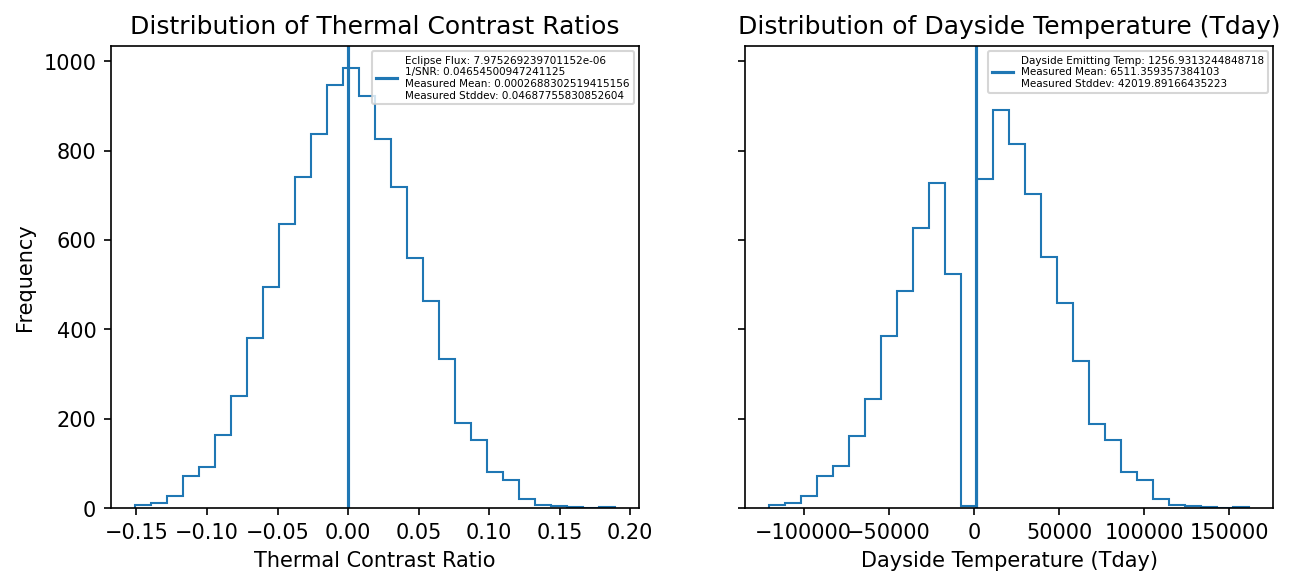

In [168]:
# Define the integrand function
def integrand(wavelength, planet_radius, star_radius, star_temp, eclipse_flux_ratio):
    term = ((planet_radius / star_radius) ** 2 * (np.exp(h * c / (wavelength * k_B * star_temp)) - 1) / eclipse_flux_ratio) + 1
    return h * c / (wavelength * k_B * np.log(term))

# Define the integrate range function
def integrate_range(w_range, planet_radius, star_radius, star_temp, eclipse_flux_ratio):
    lower_bound, upper_bound = w_range
    integral, _ = integrate.quad(integrand, lower_bound, upper_bound, args=(planet_radius, star_radius, star_temp, eclipse_flux_ratio))
    return integral / (upper_bound - lower_bound)

# Wrapper function to handle vectorization
def calculate_tday_for_vals(vals, planet_radius, star_radius, star_temp, w_range):
    tday_vals = np.array([integrate_range(w_range, planet_radius, star_radius, star_temp, val) for val in vals])
    return tday_vals

# Assuming nirspec.table is defined and getPlanet is implemented
nirspec.table = getPlanet(nirspec.table, "HIP-33609b")

# Generate random values for ESM
vals = (1/nirspec.table["ESM Estimate 1.1-1.95um"][0]) * np.random.randn(10000) + nirspec.table["Eclipse Flux Ratio 1.1-1.95um"][0]

# Extract the constants from nirspec.table
planet_radius = nirspec.table["Planet Radius [Rjup]"][0] * const.R_jup.value
star_radius = nirspec.table["Star Radius [Rs]"][0] * const.R_sun.value
star_temperature = nirspec.table["Star Temperature [K]"][0]

# Calculate Tday for each value in vals
wavelength_range = (1.1e-6, 1.95e-6)  # Example range
tday_vals = calculate_tday_for_vals(vals, planet_radius, star_radius, star_temperature, wavelength_range)

# Plot the histogram of Tday values
fig, ax = plt.subplots(1,2, figsize=(10, 4), sharey=True)


ax[0].hist(vals, bins=30, histtype='step')
ax[0].set_xlabel('Thermal Contrast Ratio')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of Thermal Contrast Ratios')

ec_flux = nirspec.table["Eclipse Flux Ratio 1.1-1.95um"][0]
ec_nsr = 1/nirspec.table["ESM Estimate 1.1-1.95um"][0]
measured_mean = np.mean(vals)
measured_std = np.std(vals)

ax[0].axvline(ec_flux, label=f"Eclipse Flux: {ec_flux}\n1/SNR: {ec_nsr}\nMeasured Mean: {measured_mean}\nMeasured Stddev: {measured_std}")

ax[0].legend(fontsize=5)


ax[1].hist(tday_vals, bins=30, histtype='step')
ax[1].set_xlabel('Dayside Temperature (Tday)')

tday = nirspec.table["Dayside Emitting Temperature [K]"][0]

tday_copy = np.array([])
for i in tday_vals:
    if not np.isnan(i):
        tday_copy = np.append(tday_copy, i)
tday_vals = tday_copy
        
measured_mean = np.mean(tday_vals)
measured_std = np.std(tday_vals)

ax[1].axvline(tday, label=f"Dayside Emitting Temp: {tday}\nMeasured Mean: {measured_mean}\nMeasured Stddev: {measured_std}")

ax[1].legend(fontsize=5)

plt.title('Distribution of Dayside Temperature (Tday)')
plt.show()

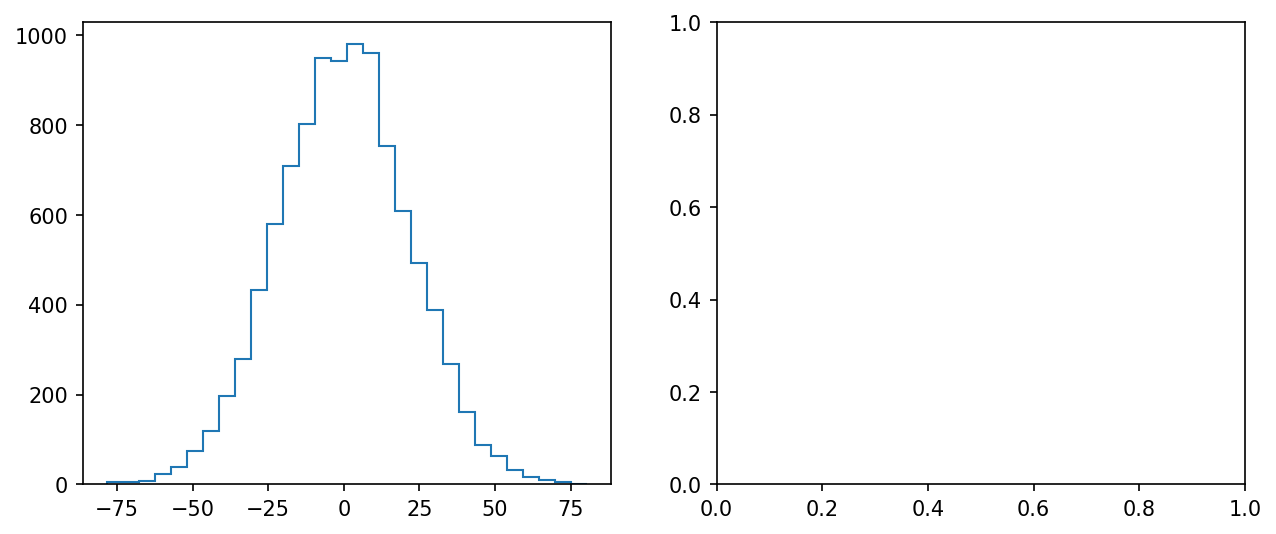

In [121]:
def integrand(wavelength):
    return h*c / (wavelength * k_B * np.log10( ((nirspec.table["Planet Radius [Rjup]"]*const.R_jup.value) / (nirspec.table["Star Radius [Rs]"] * const.R_sun.value))**2 
                                              * (np.exp(h*c / (wavelength * k_B * nirspec.table["Star Temperature [K]"])) - 1) / nirspec.table["Eclipse Flux Ratio 1.1-1.95um"] - 1))

def integrate_range(w_range):
    lower_bound, upper_bound = w_range
    integral, _ = integrate.quad(integrand, lower_bound, upper_bound)
    return integral / (upper_bound - lower_bound)

# def getTdayUnc(w_range):
    
nirspec.table = getPlanet(nirspec.table, "HIP-33609b")
    

vals = nirspec.table["ESM Estimate 1.1-1.95um"][0] * np.random.randn(10000) + nirspec.table["Eclipse Flux Ratio 1.1-1.95um"][0]




fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].hist(vals, bins=30, histtype='step')


# plt.axvline(np.mean(vals), c='black')
# plt.axvline(np.std(vals), c='black')
# plt.axvline(-np.std(vals), c='black')



plt.show()

In [23]:
# nirspec.table["Dayside Emitting Temperature Uncertainty"]

In [24]:
nirspec.getParam("ESM", iterations=1000).loc[0][1]

679.4020875734841

In [53]:
nir_HIP = getPlanet(nirspec.table, "HIP-33609b")
nir_HIP[[x for x in nir_HIP.columns if "ESM" in x]]

,ESM Estimate 1.1-1.95um
0,21.48458


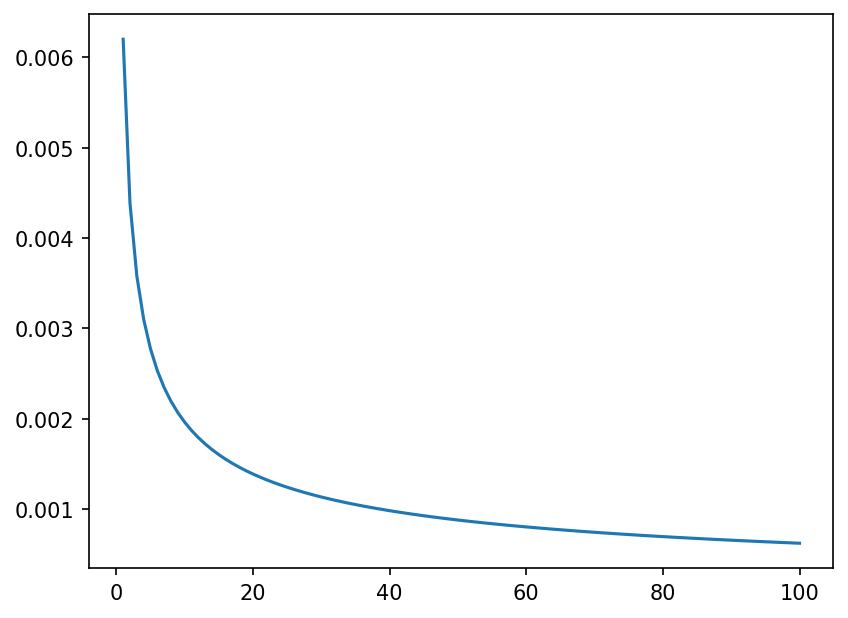

In [43]:
x = []
y = []

for i in range(1, 101):
    x.append(i)
    y.append(nirspec.getParam("Dayside Temperature Uncertainty", iterations=i).loc[0, "Eclipse Dayside Temperature Uncertainty 1.1-1.95um"])
    
plt.plot(x, y)

plt.show()

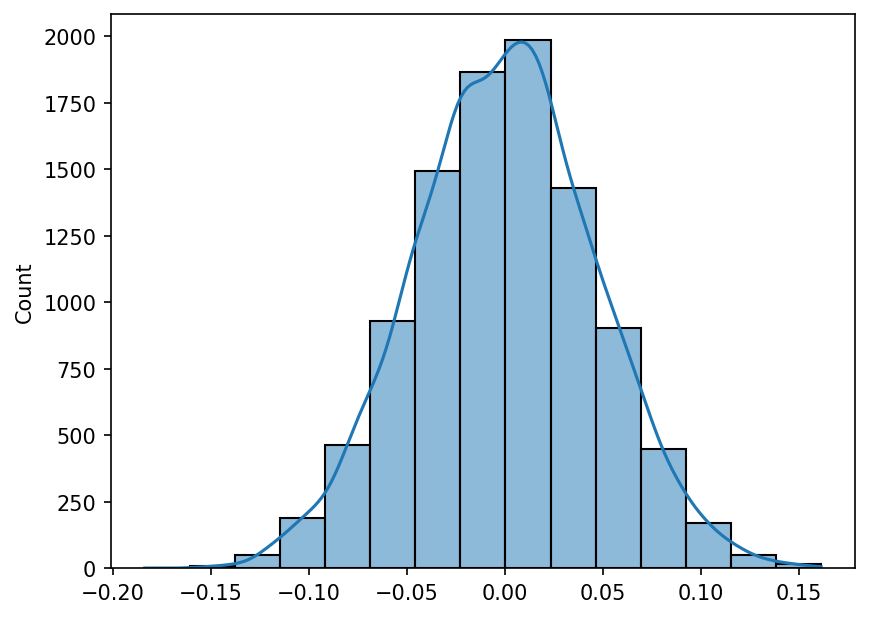

0.04654500947241125


In [62]:
mu = nir_HIP.loc[0, "Eclipse Flux Ratio 1.1-1.95um"]
sigma = 1/nir_HIP.loc[0, "ESM Estimate 1.1-1.95um"]

x = sigma*np.random.randn(10000) + mu

sns.histplot(x, bins=15, kde=True)
# sns.hist(x, bins=15, histtype='step')
plt.show()

print(sigma)